In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 데이터 생성(노이즈가 섞인 데이터, 과적합을 유도하기 위해서)
torch.manual_seed(42)
x = torch.linspace(-1, 1, 30).reshape(-1, 1)
y = torch.sin(3.14 * x) + 0.2 * torch.randn(x.size()) # 실제 노이즈

In [3]:
# 테스트 데이터
x_test = torch.linspace(-1.1, 1.1, 100).reshape(-1, 1)
y_test = torch.sin(3.14 * x_test)

In [8]:
# 모델을 정의합니다. (충분히 복잡한 모델입니다.)
class OverfitModel(nn.Module):
    def __init__ (self, dropout_rate=0.0):
        super(OverfitModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 100),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(100, 1)
        )
    def forward(self, x):
        return self.layers(x)

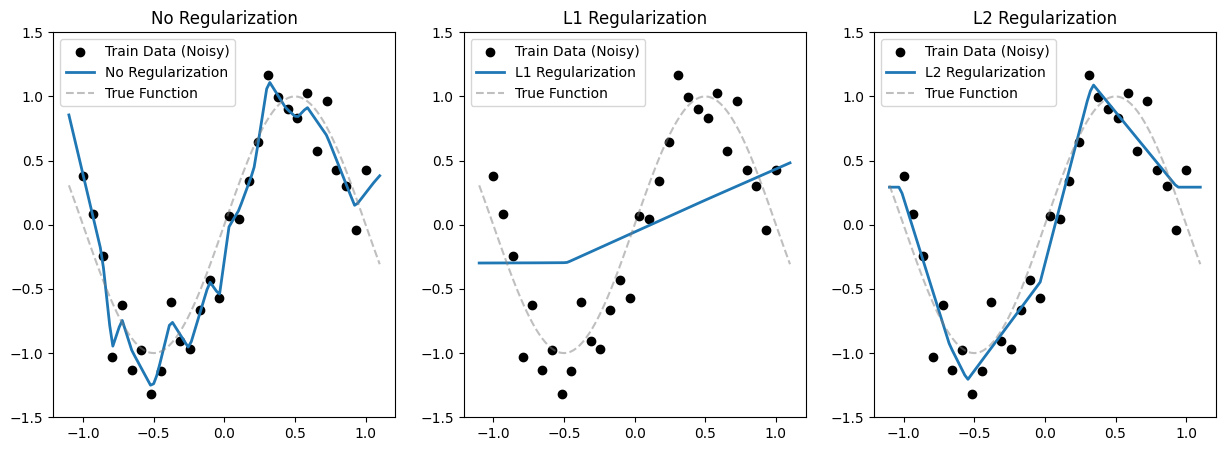

In [ ]:
def train_and_plot(model, l1_lambda=0.0, l2_lambda=0.0, title="Model"):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(1000):
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)

        # L1 규제 추가
        if l1_lambda > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss += l1_lambda * l1_penalty

        # L2 규제 추가
        if l2_lambda > 0:
            l2_penalty = sum(p.pow(2).sum() for p in model.parameters())
            loss += l2_lambda * l2_penalty

        loss.backward()
        optimizer.step()

    # 결과 시각화
    model.eval() # 테스트 모드 (드롭아웃 비활성화)
    with torch.no_grad():
        pred = model(x_test)

    plt.scatter(x, y, color='black', label='Train Data (Noisy)')
    plt.plot(x_test, pred, label=title, linewidth=2)
    plt.plot(x_test, y_test, '--', color='gray', alpha=0.5, label='True Function')
    plt.ylim(-1.5, 1.5)
    plt.legend()

plt.figure(figsize=(15, 5))

# 1. 규제가 없음
plt.subplot(1, 3, 1)
train_and_plot(OverfitModel(), title="No Regularization")
plt.title("No Regularization")

# 2. L1 규제
plt.subplot(1, 3, 2)
train_and_plot(OverfitModel(), l2_lambda=0.1, title="L1 Regularization")
plt.title("L1 Regularization")

# 3. L2 규제
plt.subplot(1, 3, 3)
train_and_plot(OverfitModel(), l1_lambda=0.005, title="L2 Regularization")
plt.title("L2 Regularization")

plt.show()

In [18]:
# 드롭아웃 유무에 따른 학습 곡선을 분석
def get_loss_history(dropout_rate):
    model = OverfitModel(dropout_rate=dropout_rate)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    # 더 많은 노이즈가 섞인 검증 데이터를 생성
    x_val = torch.linspace(-1, 1, 20).reshape(-1, 1)
    y_val =torch.sin(3.14*x_val)+0.2* torch.randn(x_val.size())

    for epoch in range(500):
        model.train()
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_val), y_val)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

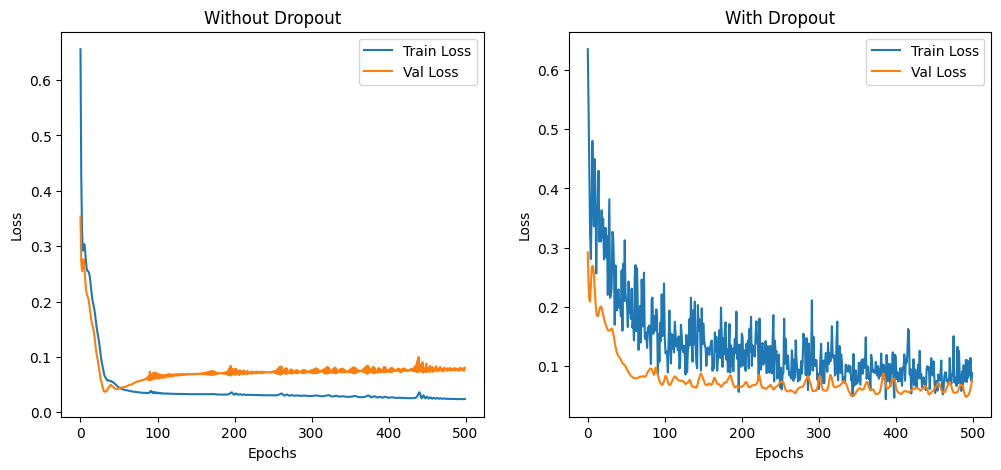

In [19]:
# 시각화
plt.figure(figsize=(12, 5))

# 드롭아웃 미적용 학습 곡선
plt.subplot(1, 2, 1)
t_loss, v_loss = get_loss_history(dropout_rate=0.0)
plt.plot(t_loss, label='Train Loss')
plt.plot(v_loss, label='Val Loss')
plt.title("Without Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# 드롭아웃 적용 학습 곡선
plt.subplot(1, 2, 2)
t_loss_dr, v_loss_dr = get_loss_history(dropout_rate=0.5)
plt.plot(t_loss_dr, label='Train Loss')
plt.plot(v_loss_dr, label='Val Loss')
plt.title("With Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()